In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

In [2]:
ds_ctrl.cells.insert(
    "reference_batch",
    np.repeat("control", ds_ctrl.cells.N),
    overwrite=True,
)

In [3]:
reference = ds_ctrl.build_mapping_reference(
    feat_key="hvgs",
    batch_columns=["reference_batch"],
)
reference

MappingReference(datastore=DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_leiden_cluster', 
            'RNA_percentMito', 'reference_batch', 'RNA_percentRibo', 'RNA_UMAP2', 'RNA_nFeatures', 
            'cluster_labels', 'RNA_UMAP1'
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
            'I__hvgs', assay_name='RNA', cell_key='I', feature_key='hvgs', reduction_path='RNA/artifacts/reduction/c6956f8922d04e7f6e4d984b086b54922ab7e4722666f1fa1fbc90a17c0467c0', ann_path='RNA/artifacts/ann_index/6e85c1c7a54f170e625bdea885c7cb033970bb28474e16d413263e13514bddeb', artifact_path='RNA/artifacts/mapping_reference/3f3092bde5d95315ba0e05a0a86de426c9b865d3fa07b165ae82153b0c66451f', model=SymphonyReferenceModel(feature_means=array([0.00816794, 0.02620863, 0.52547793, ..., 0.00812143, 0.00354939,
       0.02754458], shape=(2000,)), feature_scales=array([

In [4]:
reference = ds_ctrl.get_mapping_reference(feat_key="hvgs")

In [5]:
query_batches = pd.DataFrame(
    {
        "reference_batch": np.repeat(
            "stimulated",
            len(ds_stim.cells.fetch("ids", key="I")),
        )
    }
)
reference.map_query(
    target_assay=ds_stim.RNA,
    target_name="stim_atlas",
    target_feat_key="hvgs_stim_atlas",
    save_k=5,
    query_batches=query_batches,
)

MappingResult(n_cells=10111, correction_method='symphony', diagnostics={'featureCoverage': 1.0, 'queryBatchCount': 1.0, 'zeroNormCellCount': 0.0, 'algorithmVariant': 'symphony'}, arrays=not loaded, projection_path='RNA/artifacts/projection/3116787ecae360c...')

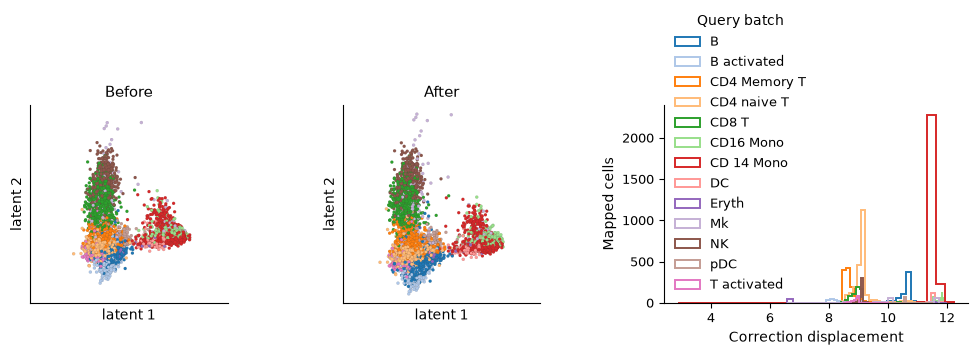

In [6]:
ds_ctrl.plots.mapping_correction(
    target_name="stim_atlas",
    batch_labels=ds_stim.cells.fetch("cluster_labels"),
)

In [7]:
mapped = ds_ctrl.get_mapping_result(
    "stim_atlas",
    load_arrays=True,
)
mapped.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1.0,
 'algorithmVariant': 'symphony'}

In [8]:
reference.map_query(
    target_assay=ds_ctrl.RNA,
    target_name="control_self_map",
    target_feat_key="hvgs_control_self_map",
    save_k=5,
    query_batches=pd.DataFrame(
        {
            "reference_batch": ds_ctrl.cells.fetch(
                "reference_batch",
                key="I",
            )
        }
    ),
)
self_mapped = ds_ctrl.get_mapping_result(
    "control_self_map",
    load_arrays=True,
)
float(
    np.linalg.norm(
        self_mapped.corrected_latent
        - self_mapped.uncorrected_latent,
        axis=1,
    ).max()
)

0.019826135482068154

In [9]:
transferred = ds_ctrl.get_target_classes(
    target_name="stim_atlas",
    reference_class_group="cluster_labels",
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "atlas_labels",
    transferred.to_numpy(),
    overwrite=True,
)

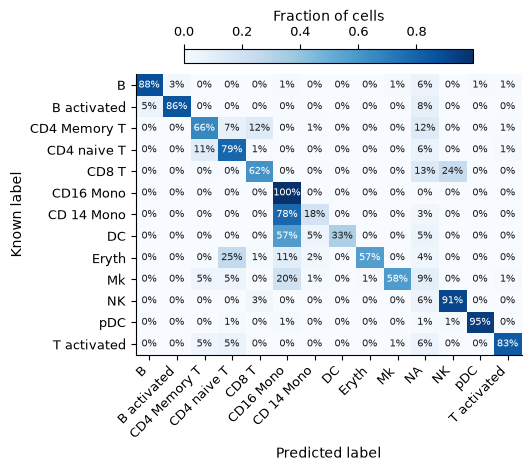

In [10]:
ds_ctrl.plots.mapping_confusion(
    target_name="stim_atlas",
    reference_class_group="cluster_labels",
    known_labels=ds_stim.cells.fetch("cluster_labels"),
    normalize="true",
    threshold_fraction=0.6,
)

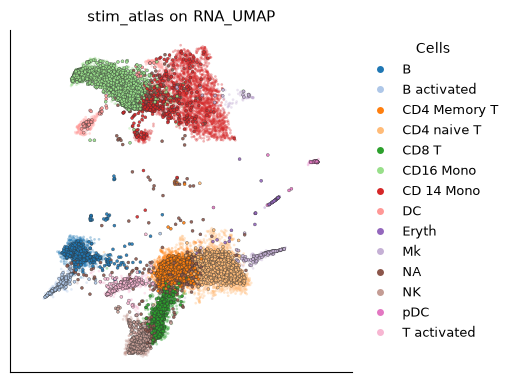

In [11]:
ds_ctrl.plots.mapping_projection(
    target_name="stim_atlas",
    reference_layout_key="RNA_UMAP",
    reference_groups="cluster_labels",
    target_groups=transferred.to_numpy(),
    ref_name="control atlas",
)